# Live lcls-belt 

In [49]:
!echo $LCLS_LATTICE

/sdf/group/ad/sw/scm/repos/optics/lcls-lattice/


In [2]:
!caget ACCL:LI21:1:L1S_S_AV

ACCL:LI21:1:L1S_S_AV           106.497


In [3]:
!caget FBCK:BCI0:1:CHRGSP

FBCK:BCI0:1:CHRGSP             0.125


In [4]:
%load_ext autoreload
%autoreload 2

from tools import isotime

from belt.tools import NpEncoder
import pandas as pd
import numpy as np

import h5py
import json
import epics

from belt.run import BELT

import sys
import os
import toml
from time import sleep, time
import datetime
from belt.evaluate import default_belt_merit
from belt.belt_impact import run_belt, evaluate_belt
from make_dashboard import make_dashboard
from pmd_beamphysics import ParticleGroup
import matplotlib.pyplot as plt
plt.style.use('default')
#import matplotlib as mpl
#mpl.use('Agg')

# Nicer plotting
#%config InlineBackend.figure_format = 'retina'

In [5]:
# Saving and loading
def save_pvdata(filename, pvdata, isotime):
    with h5py.File(filename, 'w') as h5:
        h5.attrs['isotime'] = np.bytes_(isotime)
        for k, v in pvdata.items():
            if isinstance(v, str):
                v =  np.bytes_(v)
            h5[k] = v 
def load_pvdata(filename):
    
    if not os.path.exists(filename):
        raise ValueError(f'H5 file does not exist: {filename} ')
    pvdata = {}
    with h5py.File(filename, 'r') as h5:
        isotime = h5.attrs['isotime']
        for k in h5:
            v = np.array(h5[k])        
            if v.dtype.char == 'S':
                v = str(v.astype(str))
            pvdata[k] = v
            
    return pvdata, isotime

## Set parameters

In [6]:
#phase_shift = 1.5        # shift in L1 and L2 phase
#initial_energy = 75e6    # Energy of the input beam 
input_beam =  "./example_lcls/from_Litrack_250pC.h5"  # Input beam generated from STCAV image


## Read Live PV


In [7]:
CSV = 'pv_mapping/lcls_belt.csv'
DF = pd.read_csv(CSV)#.dropna()

PVLIST = list(DF['device_pv_name'].dropna()) 


DF

,Variable,device_pv_name,pv_unit
0,Charge_inj,FBCK:BCI0:1:CHRGSP,nC
1,Charge_BC1,SIOC:SYS0:ML00:CALC254,pC
2,BC1_col_left,COLL:LI21:235:MOTR.VAL,mm
3,BC1_col_right,COLL:LI21:236:MOTR.VAL,mm
4,L1B_amplitude,ACCL:LI21:1:L1S_S_AV,MV
5,L1B_phase,ACCL:LI21:1:L1S_S_PV,deg
6,L1X_amplitude,ACCL:LI21:180:L1X_S_AV,MV
7,L1X_phase,ACCL:LI21:180:L1X_S_PV,deg
8,L2B_amplitude,ACCL:LI22:1:ADES,MV
9,L2B_phase,ACCL:LI22:1:PDES,deg


In [8]:
DF.loc[DF["Variable"] == "L1B_energy"] 

,Variable,device_pv_name,pv_unit


In [9]:
LIVE = True
if LIVE:
    MONITOR = {pvname:epics.PV(pvname) for pvname in PVLIST}
   

In [10]:
MONITOR

{'FBCK:BCI0:1:CHRGSP': <PV 'FBCK:BCI0:1:CHRGSP', count=1, type=time_double, access=read-only>,
 'SIOC:SYS0:ML00:CALC254': <PV 'SIOC:SYS0:ML00:CALC254', count=1, type=time_double, access=read-only>,
 'COLL:LI21:235:MOTR.VAL': <PV 'COLL:LI21:235:MOTR.VAL', count=1, type=time_double, access=read-only>,
 'COLL:LI21:236:MOTR.VAL': <PV 'COLL:LI21:236:MOTR.VAL', count=1, type=time_double, access=read-only>,
 'ACCL:LI21:1:L1S_S_AV': <PV 'ACCL:LI21:1:L1S_S_AV', count=1, type=time_double, access=read-only>,
 'ACCL:LI21:1:L1S_S_PV': <PV 'ACCL:LI21:1:L1S_S_PV', count=1, type=time_double, access=read-only>,
 'ACCL:LI21:180:L1X_S_AV': <PV 'ACCL:LI21:180:L1X_S_AV', count=1, type=time_double, access=read-only>,
 'ACCL:LI21:180:L1X_S_PV': <PV 'ACCL:LI21:180:L1X_S_PV', count=1, type=time_double, access=read-only>,
 'ACCL:LI22:1:ADES': <PV 'ACCL:LI22:1:ADES', count=1, type=time_double, access=read-only>,
 'ACCL:LI22:1:PDES': <PV 'ACCL:LI22:1:PDES', count=1, type=time_double, access=read-only>,
 'ACCL:LI2

In [11]:
def get_snapshot(snapshot_file=None):
        
    if LIVE:
        itime = isotime()
        pvdata =  {k:MONITOR[k].get() for k in MONITOR}
        
    else:
        pvdata, itime = load_pvdata(snapshot_file)
        itime = itime.decode('utf-8')
    
    #logger.info(f'Acquired settings from EPICS at: {itime}')
    
    epics_working_check = [val for val in pvdata.values() if val is None]
    
    if len(epics_working_check) == len(list(pvdata.keys())):
        raise Exception(f'EPICS returned None for all keys. Please check if you are able to connect to Accelerator')

    VCC_Key = None
    
    for k, v in pvdata.items():
        
        if v is None:
            raise ValueError(f'EPICS get for {k} returned None')
        
        if ':IMAGE:ARRAYDATA' in k.upper():
            VCC_Key = k
            found = False
            logger.info(f'Waiting for good {k}')
            counter = 0
            USE_VCC_LOCAL = True
            while not found and counter < 5:
                counter += 1
                if v is None:
                    continue
                if v.std() > 10:
                    found = True
                else:
                    v = MONITOR[k].get()
            if counter == 5:
                logger.info(f'VCC is not working. Defaulting to None.')
                USE_VCC_LOCAL = False
            elif np.ptp(v) < 128:
                v = v.astype(np.int8) # Downcast preemptively 
            pvdata[k] = v
        else:
            USE_VCC_LOCAL = False

    if not USE_VCC_LOCAL and VCC_Key in pvdata:
        del pvdata[VCC_Key]

    return pvdata, itime, USE_VCC_LOCAL

In [12]:
df = DF[DF['device_pv_name'].notna()]
assert len(df) > 0, 'Empty dataframe!'
    
pv_names = list(df['device_pv_name'])

pvdata, itime, USE_VCC_LOCAL = get_snapshot(None)
    
df['pv_value'] = [pvdata[k] for k in pv_names]

In [13]:
df

,Variable,device_pv_name,pv_unit,pv_value
0,Charge_inj,FBCK:BCI0:1:CHRGSP,nC,0.125000
1,Charge_BC1,SIOC:SYS0:ML00:CALC254,pC,75.743119
2,BC1_col_left,COLL:LI21:235:MOTR.VAL,mm,-2.270000
3,BC1_col_right,COLL:LI21:236:MOTR.VAL,mm,1.730000
4,L1B_amplitude,ACCL:LI21:1:L1S_S_AV,MV,106.613959
5,L1B_phase,ACCL:LI21:1:L1S_S_PV,deg,-23.893240
6,L1X_amplitude,ACCL:LI21:180:L1X_S_AV,MV,18.505823
7,L1X_phase,ACCL:LI21:180:L1X_S_PV,deg,-160.069387
8,L2B_amplitude,ACCL:LI22:1:ADES,MV,4994.338705
9,L2B_phase,ACCL:LI22:1:PDES,deg,-33.804705


In [14]:
def get_settings(csv, base_settings={}, snapshot_dir=None, snapshot_file=None):
    """
    Fetches live settings for all devices in the CSV table, and translates them to simulation inputs
     
    """
    df = DF[DF['device_pv_name'].notna()]
    assert len(df) > 0, 'Empty dataframe!'
    
    pv_names = list(df['device_pv_name'])

    pvdata, itime, USE_VCC_LOCAL = get_snapshot(snapshot_file)
    
    df['pv_value'] = [pvdata[k] for k in pv_names]
    
    # Assign impact
    #df['impact_value'] = df['impact_factor']*df['pv_value'] 
    #if 'impact_offset' in df:
    #    df['impact_value'] = df['impact_value']  + df['impact_offset']

    # Collect settings
    settings = base_settings.copy()


    HL_phase = df.loc[df["Variable"] == "L1X_phase", 'pv_value' ].values[0] 
    HL_amplitude = df.loc[df["Variable"] == "L1X_amplitude", 'pv_value' ].values[0]*1e6
    HL_gradient = HL_amplitude/0.5948

    
    L1_phase = df.loc[df["Variable"] == "L1B_phase", 'pv_value' ].values[0]
    L1_amplitude = df.loc[df["Variable"] == "L1B_amplitude", 'pv_value' ].values[0]*1e6
    L1_gradient = L1_amplitude/8.7825
                    

    L2_phase = df.loc[df["Variable"] == "L2B_phase", 'pv_value' ].values[0]
    L2_amplitude = df.loc[df["Variable"] == "L2B_amplitude", 'pv_value' ].values[0]*1e6
    L2_gradient = L2_amplitude/329.1

    
    L3_phase = df.loc[df["Variable"] == "L3B_phase", 'pv_value' ].values[0]
    L3_amplitude = df.loc[df["Variable"] == "L3B_amplitude", 'pv_value' ].values[0]*1e6
    L3_gradient = L3_amplitude/552.9 

    

    
    BC1_energy = df.loc[df["Variable"] == "BC1_energy", 'pv_value' ].values[0]
    #BC1_rigidity = (df.loc[df["Variable"] == "BCX11", 'pv_value' ].values[0] + df.loc[df["Variable"] == "BCX12", 'pv_value' ].values[0] +
    #         df.loc[df["Variable"] == "BCX13", 'pv_value' ].values[0] + df.loc[df["Variable"] == "BCX14", 'pv_value' ].values[0])/4/10
    #BC1_angle = BC1_rigidity/(3.3356*BC1_energy)
   

    BC2_energy = df.loc[df["Variable"] == "BC2_energy", 'pv_value' ].values[0]
    #BC2_rigidity = (df.loc[df["Variable"] == "BCX21", 'pv_value' ].values[0] + df.loc[df["Variable"] == "BCX22", 'pv_value' ].values[0] +
    #         df.loc[df["Variable"] == "BCX23", 'pv_value' ].values[0] + df.loc[df["Variable"] == "BCX24", 'pv_value' ].values[0])/4/10
    #BC2_angle = BC2_rigidity/(3.3356*BC2_energy)
  


    BC1_rigidity = df.loc[df["Variable"] == "BX12", 'pv_value' ].values[0] /10
    BC1_angle = BC1_rigidity/(3.3356*BC1_energy)

    BC2_rigidity = df.loc[df["Variable"] == "BX21", 'pv_value' ].values[0]/10

    BC2_angle = BC2_rigidity/(3.3356*BC2_energy)


    initial_energy = df.loc[df["Variable"] == "DL1_energy", 'pv_value'].values[0]*1e9

    BC1_energy_increment =BC1_energy*1e9 - (initial_energy + L1_amplitude*np.cos(L1_phase/180*np.pi) +  HL_amplitude*np.cos(HL_phase/180*np.pi))
    #BC1_energy_increment =BC1_energy*1e9 - (90e6 + L1_energy*1e6 )
    BC2_energy_increment = BC2_energy*1e9 - (BC1_energy*1e9 + L2_amplitude*np.cos(L2_phase/180*np.pi))

    settings["BC1:angle"] = BC1_angle
    settings["BC2:angle"] = BC2_angle
    settings["L1_amplitude"] = L1_amplitude
    settings["L2_amplitude"] = L2_amplitude
    settings["L1:gradient"] = L1_gradient
    settings["L1:phase_deg"] = L1_phase #+ phase_shift
    settings["L2:gradient"] = L2_gradient
    settings["L2:phase_deg"] = L2_phase #+ phase_shift
    settings["L3:gradient"] = L3_gradient
    settings["L3:phase_deg"] = L3_phase 
    settings["HL:gradient"] = HL_gradient
    settings["HL:phase_deg"] = HL_phase 
    settings["EBC1:energy_increment"] = BC1_energy_increment
    settings["EBC2:energy_increment"] = BC2_energy_increment
    settings["Q0"] = df.loc[df["Variable"] == "Charge_inj", 'pv_value'].values[0]*1e-9
    settings["Q1"] = df.loc[df["Variable"] == "Charge_BC1", 'pv_value'].values[0]*1e-12
    settings["BC1_current"] = df.loc[df["Variable"] == "BC1_current", 'pv_value'].values[0]
    settings["BC2_current"] = df.loc[df["Variable"] == "BC2_current", 'pv_value'].values[0]

    #update initial particle and charge
    if "Impact_particles" in settings.keys():
        print("setting initial energy  = ", initial_energy/1e6, "MeV")
        print("setting initial charge  = ", settings["Q0"]*1e12, "pC")
        P = ParticleGroup(settings["Impact_particles"])
        P.pz += -P["mean_pz"] + initial_energy
        P.charge = settings["Q0"]
        new_particle_file = "./particles.h5"
        P.write(new_particle_file)
        settings["Impact_particles"] = new_particle_file
        
    
    #if DEBUG:
    #    settings['total_charge'] = 0
    #else:
    #    settings['total_charge'] = 1 # Will be updated with particles

    # VCC image
    #if USE_VCC_LOCAL:
    #    logger.info('Getting VCC Live Distgen')
    #    dfile, img, cutimg = get_live_distgen_xy_dist(filename=DISTGEN_LASER_FILE, vcc_device=VCC_DEVICE, pvdata=pvdata)  
    #    settings['distgen:xy_dist:file'] = dfile
    #elif USE_SAVED_VCC:
    #    settings['distgen:xy_dist:file'] = SAVED_VCC
    #    img, cutimg = None, None
    #else:
    #    img, cutimg = None, None
        #settings['distgen:r_dist:max_r:value'] = 0.35 # TEMP     
        
    if snapshot_dir and not snapshot_file:
        filename = os.path.abspath(os.path.join(snapshot_dir, f'{MODEL}-snapshot-{itime}.h5'))
    #    total_charge_pC = settings['distgen:total_charge:value']
    #    if total_charge_pC < MIN_CHARGE_pC:
    #        logger.info(f'total charge is too low: {total_charge_pC:.2f} pC, not saving snapshot')         
    #    else:
        save_pvdata(filename, pvdata, itime)
    #        logger.info(f'EPICS shapshot written: {filename}')
        
        
    return settings, df, itime

In [15]:
def convertToDatedFormat(destionation_folder):
    curr_date = datetime.date.today()
    year,month,day = curr_date.strftime('%Y'),curr_date.strftime('%m'),curr_date.strftime('%d')
    destionation_folder_dated = destionation_folder + "/" + year + "/" + month + "/" + day

    if not os.path.exists(destionation_folder_dated):
        os.makedirs(destionation_folder_dated)
    
    return destionation_folder_dated

In [16]:
dat = {}

MODEL = 'LCLS'
HOST = 's3df'
ARCHIVE_DIR = './archive'

SNAPSHOT_DIR = './snapshot'
SUMMARY_OUTPUT_DIR = './summary'
PLOT_OUTPUT_DIR = './plot'

SETTINGS0 = {"Impact_particles": input_beam}
CONFIG0 = {"input": "example_lcls/belt.in", "workdir": os.environ.get("SCRATCH")}
PREFIX = f'lume-belt-live-demo-{HOST}-{MODEL}'


DASHBOARD_KWARGS = {'outpath':PLOT_OUTPUT_DIR,            
                    'name' : PREFIX
                   }    

SNAPSHOT = None
SNAPSHOT_DIR_DATED = convertToDatedFormat(SNAPSHOT_DIR)
ARCHIVE_DIR_DATED = convertToDatedFormat(ARCHIVE_DIR)
SUMMARY_OUTPUT_DIR_DATED = convertToDatedFormat(SUMMARY_OUTPUT_DIR)
settings, df, itime = get_settings(CSV,
                                                           SETTINGS0,
                                                           snapshot_dir=SNAPSHOT_DIR_DATED,
                                                          snapshot_file=SNAPSHOT)       

setting initial energy  =  135.0 MeV
setting initial charge  =  125.00000000000001 pC


In [17]:
settings

{'Impact_particles': './particles.h5',
 'BC1:angle': np.float64(0.0934766622511541),
 'BC2:angle': np.float64(0.03696363750888448),
 'L1_amplitude': np.float64(106480748.68683088),
 'L2_amplitude': np.float64(4994095415.342652),
 'L1:gradient': np.float64(12124195.694486862),
 'L1:phase_deg': np.float64(-23.904127255569747),
 'L2:gradient': np.float64(15175008.858531304),
 'L2:phase_deg': np.float64(-33.79008615041888),
 'L3:gradient': np.float64(16238521.818205448),
 'L3:phase_deg': np.float64(0.0),
 'HL:gradient': np.float64(31087205.262898788),
 'HL:phase_deg': np.float64(-160.30244356972088),
 'EBC1:energy_increment': np.float64(5061348.832359344),
 'EBC2:energy_increment': np.float64(129503624.99967194),
 'Q0': np.float64(1.25e-10),
 'Q1': np.float64(7.67318577984e-11),
 'BC1_current': np.float64(114.31790210482374),
 'BC2_current': np.float64(3379.760507775267)}

In [18]:



# Patch this into the function below for the dashboard creation
def my_merit(belt_object, itime):
    # Collect standard output statistics
    merit0 = default_belt_merit(belt_object)
    
    PLOT_OUTPUT_DIR_DATED = convertToDatedFormat(PLOT_OUTPUT_DIR)
    #Overriding at runtime to save in dated folders
    DASHBOARD_KWARGS["outpath"] = PLOT_OUTPUT_DIR_DATED
    
    # Make the dashboard from the evaluated object
    plot_file = make_dashboard(belt_object, itime=itime, **DASHBOARD_KWARGS)
    #print('Dashboard written:', plot_file)
    #logger.info(f'Dashboard written: {plot_file}')
    
    # Make all readable
    os.chmod(plot_file, 0o644)
    
    # Assign extra info
    merit0['plot_file'] = plot_file    
    merit0['isotime'] = itime
    
    # Clear any buffers
    plt.close('all')

    return merit0




In [19]:
# Patch this into the function below for the dashboard creation
def find_linac_info(E: BELT, ele_name: str):
    for ele in E.input.lattice_lines:
        if ele.name == ele_name:
            freq = ele.frequency
            V = ele.length*ele.gradient
            phase_deg = ele.phase_deg
            return freq, V, phase_deg
    print("element not found!")
    return

def my_belt_merit(E: BELT):
    """
    merit function to operate on an evaluated LUME-BELT object E.

    Returns dict of scalar values
    """
    # Check for error
    if E.output.run.error:
        return {"error": True}
    else:
        m = {"error": False}

    # Gather stat output
    stats_keys = [
        "kinetic_energy",
        "gamma",
        "mean_z",
        "rms_z",
        "mean_delta_gamma",
        "rms_delta_gamma",
    ]
    for k in stats_keys:
        m["end_" + k] = getattr(E.output.stats, k)[-1]

    m["run_time"] = E.output.run.run_time

    #-----------------------------------------------------------#
    #         for RF phase feed back                            #
    #-----------------------------------------------------------#
    P_L1 = E.output.particle_distributions[109].to_particlegroup()
    P_BC1 = E.output.particle_distributions[113].to_particlegroup()
    P_L2 = E.output.particle_distributions[115].to_particlegroup()
    P_BC2 = E.output.particle_distributions[117].to_particlegroup()

    #beam chirp after L1
    pg = P_L1
    x = pg.z
    y = (pg.energy - pg['mean_energy'])/pg['mean_energy']
    chirp_L1,_  = np.polyfit(x, y, 1)

    #beam chirp after L2
    pg = P_L2
    x = pg.z
    y = (pg.energy - pg['mean_energy'])/pg['mean_energy']
    chirp_L2,_  = np.polyfit(x, y, 1)

    #bunch length after BC1
    BC1_sigma_t = P_BC1['sigma_t']
    BC1_bunch_length = BC1_sigma_t*np.sqrt(10)
    BC1_current = P_BC1.charge/BC1_bunch_length

    #bunch length after BC2
    BC2_sigma_t = P_BC2['sigma_t']
    BC2_bunch_length = BC2_sigma_t*np.sqrt(12)
    BC2_current = P_BC2.charge/BC2_bunch_length

    freq, V, phase_deg = find_linac_info(E, ele_name)

    m['L1_chirp'] = chirp_L1
    m['L2_chirp'] = chirp_L2
    m['BC1_sigma_t'] = BC1_sigma_t
    m['BC1_bunch_length'] = BC1_bunch_length
    m['BC1_current'] = BC1_current
    m['BC2_sigma_t'] = BC2_sigma_t
    m['BC2_bunch_length'] = BC2_bunch_length
    m['BC2_current'] = BC2_current
    


    #--------------------------------------------------------------#
    P = E.output.particle_distributions[201].to_particlegroup()
    P_init = E.output.particle_distributions[101].to_particlegroup()

    # All impact particles read back have status==1
    #
    ntotal = len(P_init)
    nlost = ntotal - len(P)

    m["end_n_particle_loss"] = nlost

    # Get live only for stat calcs
    P = P.where(P.status == 1)

    # No live particles
    if len(P) == 0:
        return {"error": True}

    # Special
    m["end_total_charge"] = P["charge"]
    m["end_higher_order_energy_spread"] = P["higher_order_energy_spread"]

    # Remove annoying strings
    if "why_error" in m:
        m.pop("why_error")

    return m

def my_merit(belt_object, itime):
    # Collect standard output statistics
    merit0 = my_belt_merit(belt_object)
    
    PLOT_OUTPUT_DIR_DATED = convertToDatedFormat(PLOT_OUTPUT_DIR)
    #Overriding at runtime to save in dated folders
    DASHBOARD_KWARGS["outpath"] = PLOT_OUTPUT_DIR_DATED
    
    # Make the dashboard from the evaluated object
    plot_file = make_dashboard(belt_object, itime=itime, **DASHBOARD_KWARGS)
    #print('Dashboard written:', plot_file)
    #logger.info(f'Dashboard written: {plot_file}')
    
    # Make all readable
    os.chmod(plot_file, 0o644)
    
    # Assign extra info
    merit0['plot_file'] = plot_file    
    merit0['isotime'] = itime
    
    # Clear any buffers
    plt.close('all')

    return merit0

In [ ]:
def linac_phase_feedback_from_current(
    h_sim,
    R56,
    I_sim,
    I_meas,
    V,
    E,
    lambda_rf,
    phi_old,
    gain_h=0.3,
    max_step_deg=0.5,
    min_current=1e-12
):
    """
    One-step feedback update for linac phase using measured
    post-compressor current.

    Returns:
        phi_new, diagnostics
    """

    I_sim = max(I_sim, min_current)
    I_meas = max(I_meas, min_current)

    A_sim = 1.0 + R56 * h_sim

    current_error_log = np.log(I_meas / I_sim)

    delta_h = -gain_h * A_sim / R56 * current_error_log

    k_rf = 2.0 * np.pi / lambda_rf
    dh_dphi = -(V * k_rf / E) * np.cos(phi_old)

    if abs(dh_dphi) < 1e-12:
        raise ValueError("Phase-to-chirp sensitivity is too small.")

    delta_phi = delta_h / dh_dphi

    max_step = np.deg2rad(max_step_deg)
    delta_phi_applied = np.clip(delta_phi, -max_step, max_step)

    phi_new = phi_old + delta_phi_applied

    diagnostics = {
        "A_sim": A_sim,
        "current_error_log": current_error_log,
        "delta_h": delta_h,
        "dh_dphi": dh_dphi,
        "delta_phi_raw_rad": delta_phi,
        "delta_phi_applied_rad": delta_phi_applied,
        "delta_phi_applied_deg": np.rad2deg(delta_phi_applied),
        "phi_new_rad": phi_new,
        "phi_new_deg": np.rad2deg(phi_new),
    }

    return phi_new, diagnostics

In [ ]:
def run1_lcls():
    dat = {}

    SNAPSHOT_DIR_DATED = convertToDatedFormat(SNAPSHOT_DIR)
    ARCHIVE_DIR_DATED = convertToDatedFormat(ARCHIVE_DIR)
    SUMMARY_OUTPUT_DIR_DATED = convertToDatedFormat(SUMMARY_OUTPUT_DIR)
        
    # Acquire settings
    mysettings, df,  itime = get_settings(CSV,
                                                           SETTINGS0,
                                                           snapshot_dir=SNAPSHOT_DIR_DATED,
                                                          snapshot_file=SNAPSHOT)        
    print(mysettings)
    dat['isotime'] = itime
    
    # Record inputs
    dat['inputs'] = mysettings
    dat['config'] = CONFIG0
    dat['pv_mapping_dataframe'] = df.to_dict()
    

    t0 = time()
    
    
    #-------Initial Run-------------------------------------------------
    outputs = evaluate_belt(CONFIG0, mysettings,
                                       merit_f=lambda x: my_merit(x, itime),
                                       archive_path=ARCHIVE_DIR_DATED,
                                        verbose=False )

    dat['outputs_run0'] =  outputs  

    #-------Second Run, tweak BC1 collimator to get the right charge----------------
    run1_out = BELT.from_archive(outputs['archive'])
    #particles after BC1
    pg = run1_out.output.particle_distributions[111]
    z = pg.z
    # set collimator to cut the right charge
    Q0 = mysettings["Q0"]
    Q1 = mysettings["Q1"]

    print("Second run, cutting beam charge from ", Q0*1e12, "pC to ", Q1*1e12, "pC")
    
    f = Q1 / Q0
    alpha = 0.5 * (1 - f)
    zmin = np.quantile(z, alpha)
    zmax = np.quantile(z, 1 - alpha)
    mysettings["BC1_Col:zmin"] = zmin
    mysettings["BC1_Col:zmax"] = zmax
    
    
    print(mysettings)
    
    outputs = evaluate_belt(CONFIG0, mysettings,
                                       merit_f=lambda x: my_merit(x, itime),
                                       archive_path=ARCHIVE_DIR_DATED,
                                        verbose=False )
    
    dat['outputs_run1'] =  outputs
    #-----Thrid run, tune L1 phase to match BC1 current----------------------------
    
    BC1_current_sim = outputs['BC1_current']
    L1_chirp_sim = outputs['L1_chirp']
    BC1_current_live = mysettings['BC1_current']

    BC1_angle = mysettings['BC1:angle']
    Ldb = 2.4456
    Lb = 2.034970000e-01

    BC1_R56 = 2*BC1_angle**2*(Ldb + 2/3*Lb)
    print("Third run, tune L1 phase to match BC1 current from ", BC1_current_sim, "A to ", BC1_current_live, "A")
    print(f'BC1_R56 = {BC1_R56}')
    while np.abs(BC1_current_live - BC1_current_sim)/BC1_current_live > 0.1:
        
        #calculate new L1 phase
        #r = BC1_current_live/BC1_current_sim
        #L1_new_chirp = ((1 - r) + BC1_R56*L1_chirp_sim)/(r*BC1_R56)
        if BC1_R56*L1_chirp_sim + 1 < 0:
            print("BC1 Overcompression")
        L1_new_chirp = (BC1_current_sim/BC1_current_live*np.abs(1 + BC1_R56*L1_chirp_sim) - 1)/BC1_R56

        
        sin_L1_phase = L1_new_chirp/L1_chirp_sim*np.sin(mysettings['L1:phase_deg']/180*np.pi)
        L1_new_phase = np.asin(sin_L1_phase)
        L1_new_phase_deg = L1_new_phase/np.pi*180

        print("Change L1 phase from ", mysettings['L1:phase_deg'], "deg to", L1_new_phase_deg, "deg")
    

        mysettings['EBC1:energy_increment'] += mysettings['L1_amplitude']*np.cos(mysettings['L1:phase_deg']/180*np.pi) - mysettings['L1_amplitude']*np.cos(L1_new_phase_deg/180*np.pi)
        mysettings['L1:phase_deg'] = L1_new_phase_deg

        outputs = evaluate_belt(CONFIG0, mysettings,
                                       merit_f=lambda x: my_merit(x, itime),
                                       archive_path=ARCHIVE_DIR_DATED,
                                        verbose=False )

        BC1_current_sim = outputs['BC1_current']
        L1_chirp_sim = outputs['L1_chirp']

    dat['outputs_run2'] =  outputs
    #-----Fourth run, tune L2 phase to match BC2 current----------------------------
    
    BC2_current_sim = outputs['BC2_current']
    L2_chirp_sim = outputs['L2_chirp']
    BC2_current_live = mysettings['BC2_current']

    BC2_angle = mysettings['BC2:angle']
    Ldb = 9.866942
    Lb = 5.491250000E-01

    BC2_R56 = 2*BC2_angle**2*(Ldb + 2/3*Lb)
    print("Fourth run, tune L2 phase to match BC2 current from ", BC2_current_sim, "A to ", BC2_current_live, "A")

    
    while np.abs(BC2_current_live - BC2_current_sim)/BC2_current_live > 0.1:
        
    #calculate new L2 phase
    #r = BC2_current_live/BC2_current_sim
    #L2_new_chirp = ((1 - r) + BC2_R56*L2_chirp_sim)/(r*BC2_R56)

        if BC2_R56*L2_chirp_sim + 1 < 0:
            print("BC2 Overcompression")
        L2_new_chirp = (BC2_current_sim/BC2_current_live*np.abs(1 + BC2_R56*L2_chirp_sim) - 1)/BC2_R56
        
   
        sin_L2_phase = L2_new_chirp/L2_chirp_sim*np.sin(mysettings['L2:phase_deg']/180*np.pi)
        L2_new_phase = np.asin(sin_L2_phase)
        L2_new_phase_deg = L2_new_phase/np.pi*180
        print("Change L2 phase from ", mysettings['L2:phase_deg'], "deg to", L2_new_phase_deg, "deg")
    

        mysettings['EBC2:energy_increment'] += mysettings['L2_amplitude']*np.cos(mysettings['L2:phase_deg']/180*np.pi) - mysettings['L2_amplitude']*np.cos(L2_new_phase_deg/180*np.pi)
        mysettings['L2:phase_deg'] = L2_new_phase_deg

        outputs = evaluate_belt(CONFIG0, mysettings,
                                       merit_f=lambda x: my_merit(x, itime),
                                       archive_path=ARCHIVE_DIR_DATED,
                                        verbose=False )
        BC2_current_sim = outputs['BC2_current']
        L2_chirp_sim = outputs['L2_chirp']
        
        
    dat['outputs'] =  outputs   
    
    fname = fname=f'{SUMMARY_OUTPUT_DIR_DATED}/{PREFIX}-{itime}.json'

    json.dump(dat, open(fname, 'w'), cls=NpEncoder)
    #logger.info(f'Summary output written: {fname}')
    return dat

In [45]:
result = run1_lcls()

setting initial energy  =  135.0 MeV
setting initial charge  =  125.00000000000001 pC
{'Impact_particles': './particles.h5', 'BC1:angle': np.float64(0.09347642323240246), 'BC2:angle': np.float64(0.03696371593866081), 'L1_amplitude': np.float64(106054411.93403351), 'L2_amplitude': np.float64(4993156354.458583), 'L1:gradient': np.float64(12075651.800060747), 'L1:phase_deg': np.float64(-23.563498970671546), 'L2:gradient': np.float64(15172155.437431123), 'L2:phase_deg': np.float64(-33.679335965936765), 'L3:gradient': np.float64(16194319.036401466), 'L3:phase_deg': np.float64(0.0), 'HL:gradient': np.float64(31134669.024060644), 'HL:phase_deg': np.float64(-160.07227457364087), 'EBC1:energy_increment': np.float64(5198710.97892499), 'EBC2:energy_increment': np.float64(124924089.8379488), 'Q0': np.float64(1.25e-10), 'Q1': np.float64(7.6670771616e-11), 'BC1_current': np.float64(101.55654149257117), 'BC2_current': np.float64(3720.7978164241777)}
Rerefence energy not defined. Using the mean energy

In [51]:
result

{'isotime': '2026-05-28T13:09:39-07:00',
 'inputs': {'Impact_particles': './particles.h5',
  'BC1:angle': np.float64(0.09347642323240246),
  'BC2:angle': np.float64(0.03696371593866081),
  'L1_amplitude': np.float64(106054411.93403351),
  'L2_amplitude': np.float64(4993156354.458583),
  'L1:gradient': np.float64(12075651.800060747),
  'L1:phase_deg': np.float64(-22.82023978451906),
  'L2:gradient': np.float64(15172155.437431123),
  'L2:phase_deg': np.float64(-34.16233487513797),
  'L3:gradient': np.float64(16194319.036401466),
  'L3:phase_deg': np.float64(0.0),
  'HL:gradient': np.float64(31134669.024060644),
  'HL:phase_deg': np.float64(-160.07227457364087),
  'EBC1:energy_increment': np.float64(4656920.068886101),
  'EBC2:energy_increment': np.float64(148413283.02477598),
  'Q0': np.float64(1.25e-10),
  'Q1': np.float64(7.6670771616e-11),
  'BC1_current': np.float64(101.55654149257117),
  'BC2_current': np.float64(3720.7978164241777),
  'BC1_Col:zmin': np.float64(-0.00014161268432049

In [46]:
result['outputs']

{'error': False,
 'end_kinetic_energy': np.float64(13453329000.0),
 'end_gamma': np.float64(26328.1963),
 'end_mean_z': np.float64(-1.09795008e-05),
 'end_rms_z': np.float64(9.55172738e-06),
 'end_mean_delta_gamma': np.float64(-26.684659),
 'end_rms_delta_gamma': np.float64(23.98693),
 'run_time': 12.490809243172407,
 'L1_chirp': np.float64(-17.413857402763238),
 'L2_chirp': np.float64(-35.70421398559364),
 'BC1_sigma_t': np.float64(2.1374948380273854e-13),
 'BC1_bunch_length': np.float64(6.75935217501923e-13),
 'BC1_current': np.float64(106.2860731913197),
 'BC2_sigma_t': np.float64(6.161169940220151e-15),
 'BC2_bunch_length': np.float64(2.1342918741054807e-14),
 'BC2_current': np.float64(3366.10474282532),
 'end_n_particle_loss': 42526,
 'end_total_charge': np.float64(7.184249999999999e-11),
 'end_higher_order_energy_spread': np.float64(2255661.0403886796),
 'plot_file': './plot/2026/05/28/lume-belt-live-demo-s3df-LCLS-2026-05-28T13:09:39-07:00-dashboard.png',
 'isotime': '2026-05-28

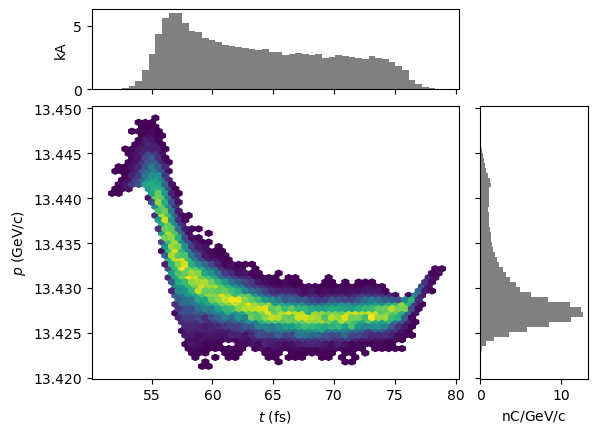

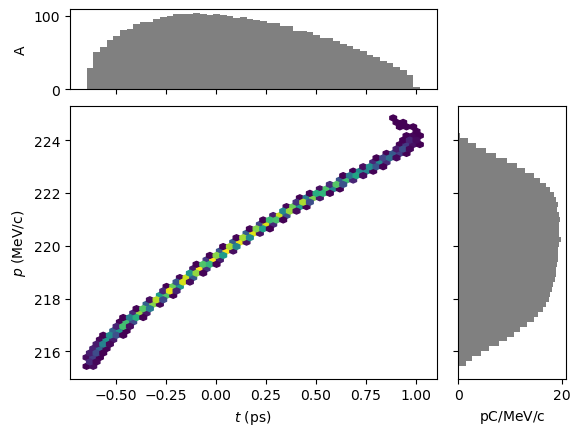

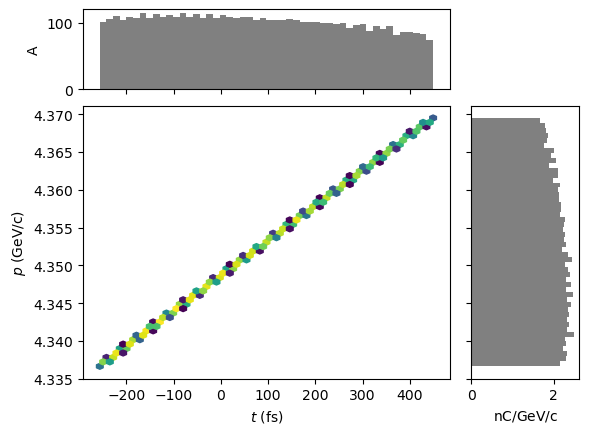

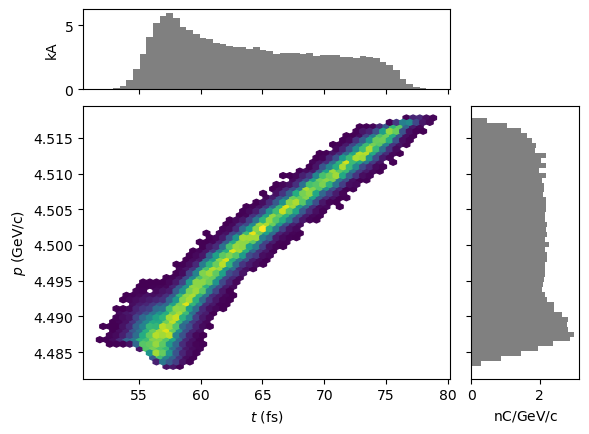

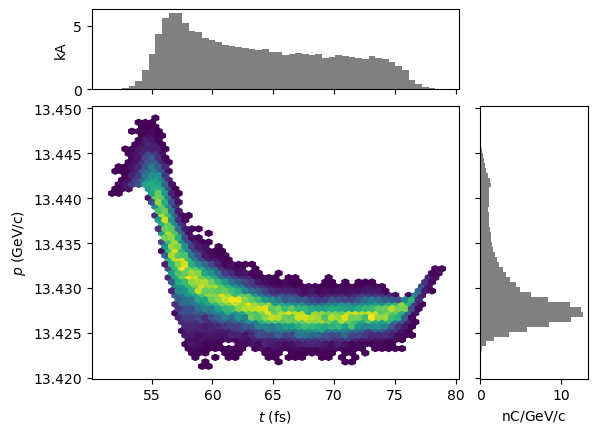

In [52]:
E = BELT.from_archive(result['outputs']['archive'])
pg = E.output.particle_distributions[111]  #BC1
pg.plot('t', 'p')

pg = E.output.particle_distributions[115]  #L2
pg.plot('t', 'p')

pg = E.output.particle_distributions[117] #BC2
pg.plot('t', 'p')

pg = E.output.particle_distributions[201]
pg.plot('t', 'p')

In [58]:
E.input.parameters.freq

2856009469.46

In [71]:
def find_linac_info(E, ele_name):
    for ele in E.input.lattice_lines:
        if ele.name == ele_name:
            freq = ele.frequency
            V = ele.length*ele.gradient
            phase_deg = ele.phase_deg
            return freq, V, phase_deg
    print("element not found!")
    return
freq, V, phase_deg = find_linac_info(E, 'L3')
V*np.cos(np.radians(phase_deg))/1e9

np.float64(8.95383899522637)

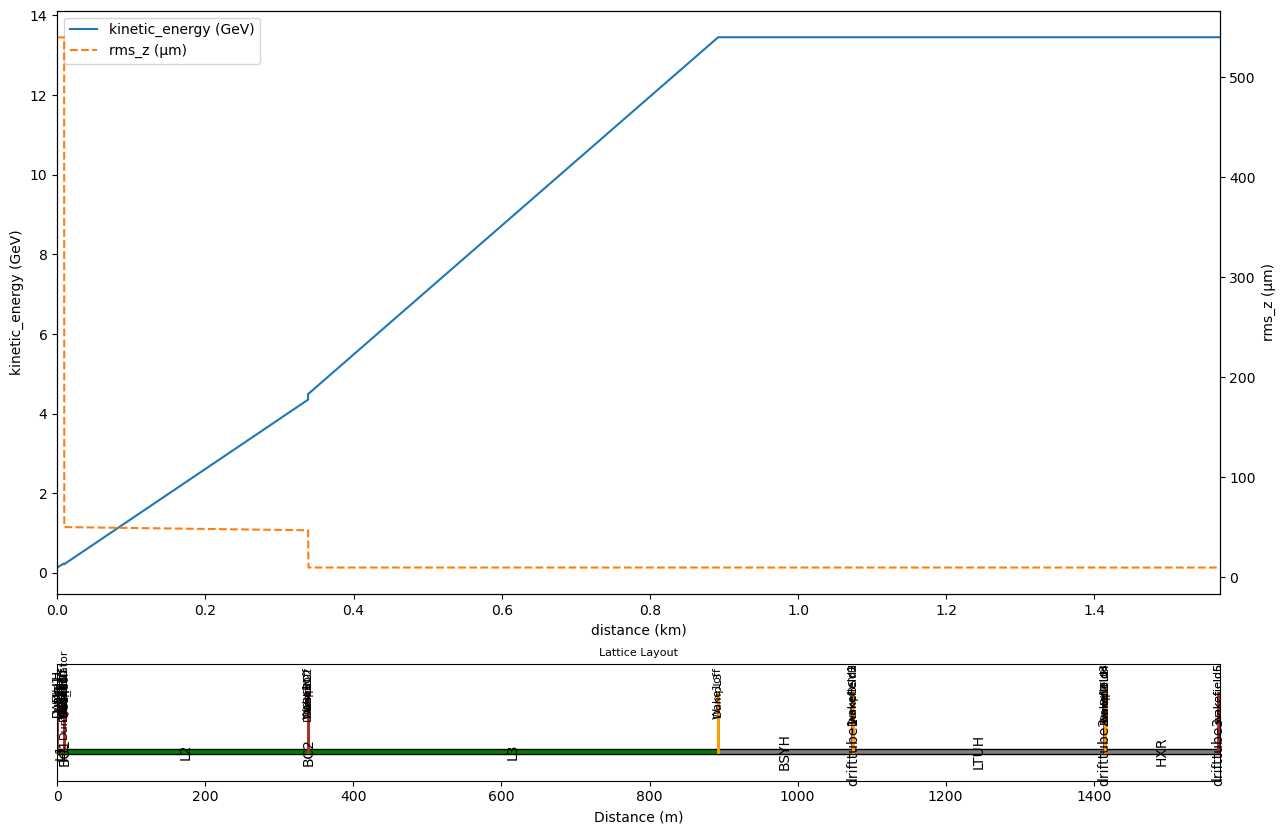

In [48]:
E.plot()

In [27]:
pg.z.shape

(55651,)

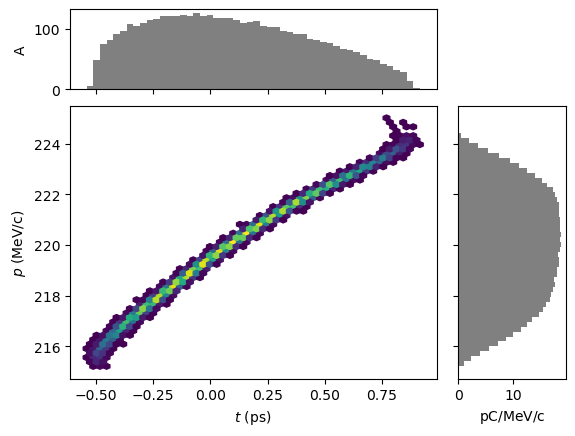

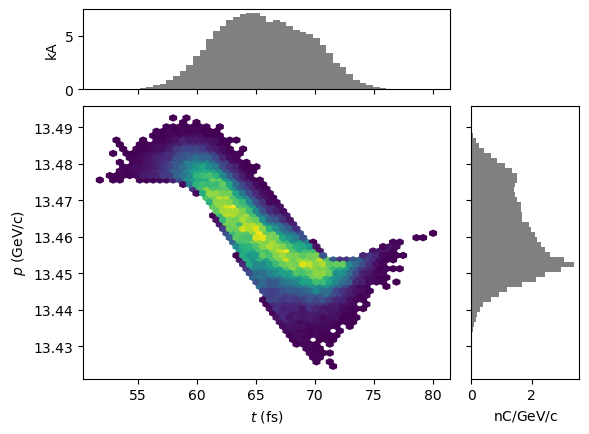

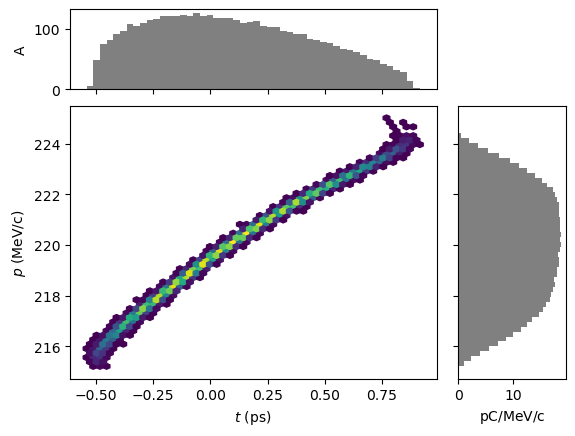

In [24]:
E = BELT.from_archive(result['outputs_run1']['archive'])
pg = E.output.particle_distributions[201]
pg.plot('t', 'p')

pg = E.output.particle_distributions[111]
pg.plot('t', 'p')

In [38]:
result['outputs']

{'error': False,
 'end_kinetic_energy': np.float64(10392510900.0),
 'end_gamma': np.float64(20338.3958),
 'end_mean_z': np.float64(-4.40427453e-05),
 'end_rms_z': np.float64(2.29964688e-05),
 'end_mean_delta_gamma': np.float64(-72.4276009),
 'end_rms_delta_gamma': np.float64(42.0120683),
 'run_time': 13.628513630479574,
 'L1_chirp': np.float64(-17.515243369340176),
 'L2_chirp': np.float64(-35.7588816835123),
 'BC1_sigma_t': np.float64(3.234592774273801e-13),
 'BC1_bunch_length': np.float64(1.0228680469828102e-12),
 'BC1_current': np.float64(193.5977964940065),
 'BC2_sigma_t': np.float64(1.6726337313017428e-14),
 'BC2_bunch_length': np.float64(5.794173210136256e-14),
 'BC2_current': np.float64(3417.657581474738),
 'end_n_particle_loss': 20790,
 'end_total_charge': np.float64(1.9802499999999997e-10),
 'end_higher_order_energy_spread': np.float64(5045280.887514814),
 'plot_file': './plot/2026/04/06/lume-belt-live-demo-s3df-LCLS-2026-04-06T03:01:30-07:00-dashboard.png',
 'isotime': '2026-0